# Datenvisualisierung
## Rotten Tomatoes Datensatz

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv('Dataset/rotten_tomatoes_movies.csv')
reviews_clean = pd.read_csv('Dataset/reviews_clean.csv')

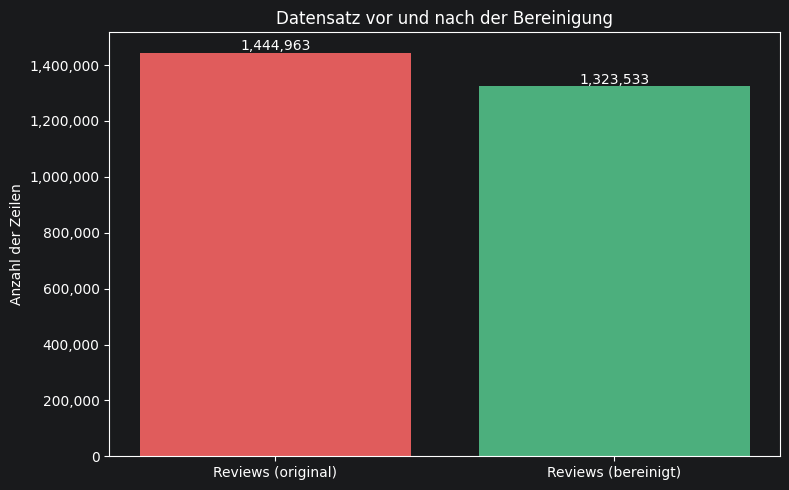

Entfernte Zeilen: 121,430 (8.4%)


In [5]:
# Datensatz vor und nach der Bereinigung
labels = ['Reviews (original)', 'Reviews (bereinigt)']
values = [1444963, len(reviews_clean)]
colors = ['#e05c5c', '#4caf7d']

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=colors)
plt.title('Datensatz vor und nach der Bereinigung')
plt.ylabel('Anzahl der Zeilen')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, val in enumerate(values):
    plt.text(i, val + 10000, f'{val:,}', ha='center')

plt.tight_layout()
plt.show()

removed = values[0] - values[1]
print(f'Entfernte Zeilen: {removed:,} ({removed/values[0]*100:.1f}%)')

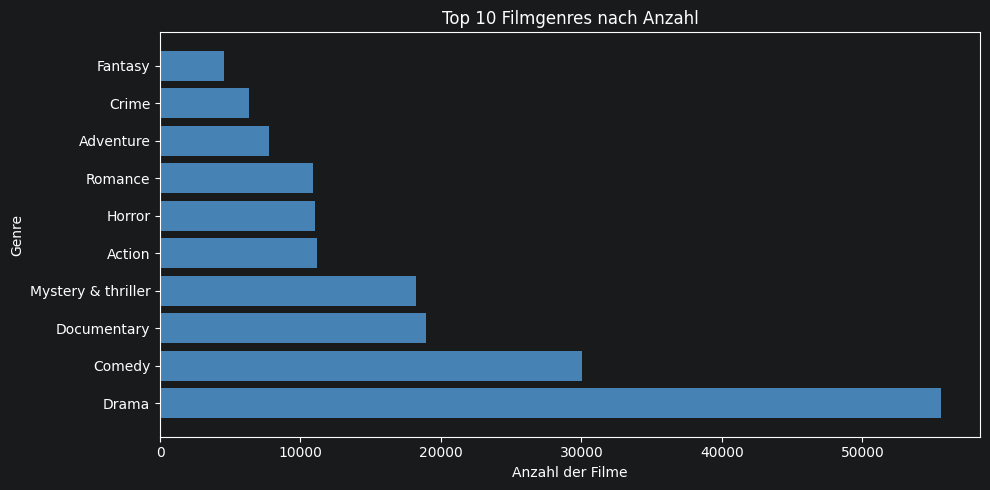

In [4]:
# Top 10 Filmgenres nach Anzahl
genre_counts = movies.dropna(subset=['genre'])
genre_counts = genre_counts.assign(genre=genre_counts['genre'].str.split(',')).explode('genre')
genre_counts['genre'] = genre_counts['genre'].str.strip()

top10 = genre_counts['genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10.index, top10.values, color='steelblue')
plt.title('Top 10 Filmgenres nach Anzahl')
plt.xlabel('Anzahl der Filme')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

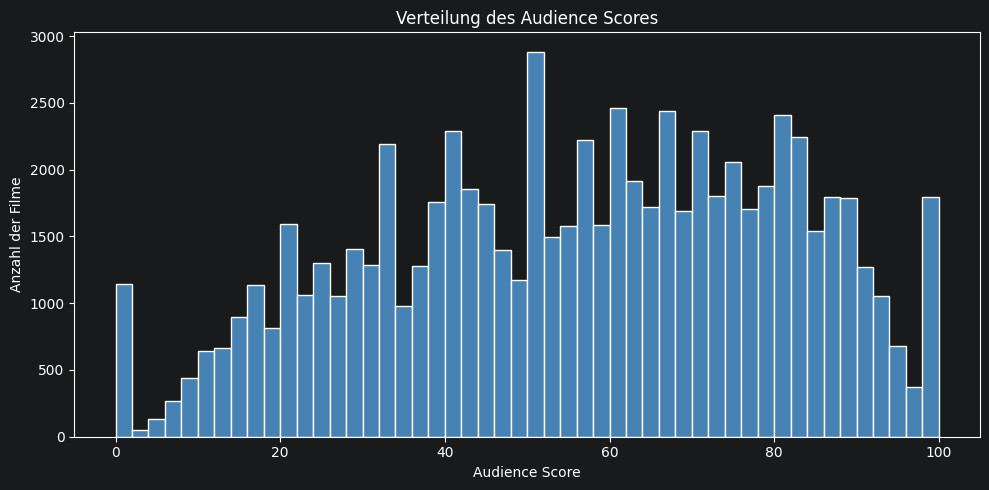

In [6]:
# Verteilung des Audience Scores
plt.figure(figsize=(10, 5))
plt.hist(movies['audienceScore'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Verteilung des Audience Scores')
plt.xlabel('Audience Score')
plt.ylabel('Anzahl der Filme')
plt.tight_layout()
plt.show()

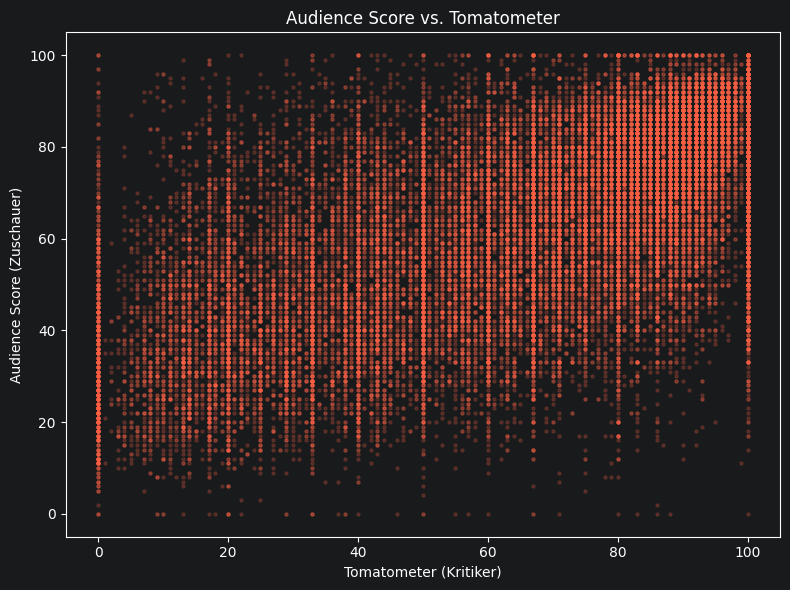

In [7]:
# Audience Score vs. Tomatometer
clean = movies.dropna(subset=['tomatoMeter', 'audienceScore'])

plt.figure(figsize=(8, 6))
plt.scatter(clean['tomatoMeter'], clean['audienceScore'], alpha=0.2, color='tomato', s=5)
plt.title('Audience Score vs. Tomatometer')
plt.xlabel('Tomatometer (Kritiker)')
plt.ylabel('Audience Score (Zuschauer)')
plt.tight_layout()
plt.show()

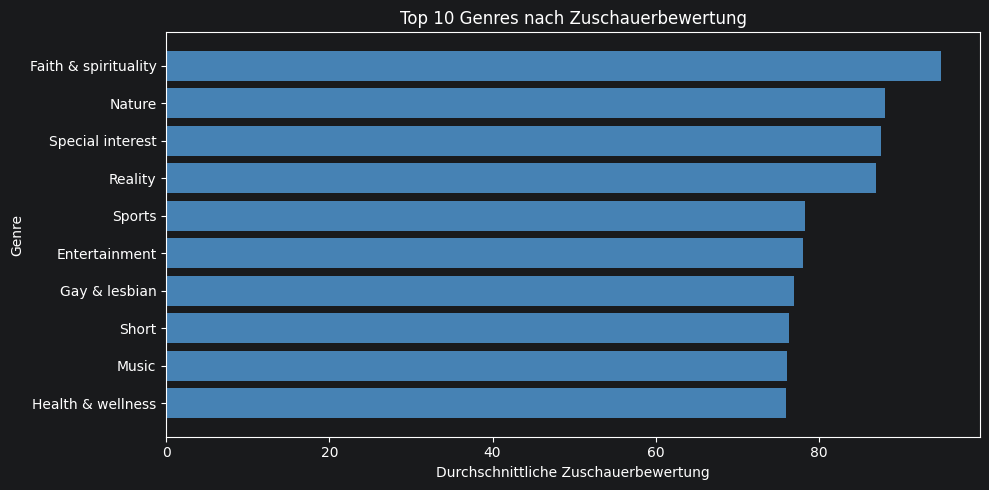

In [8]:
# Top 10 Genres nach Zuschauerbewertung
genre_scores = movies.dropna(subset=['genre', 'audienceScore'])
genre_scores = genre_scores.assign(genre=genre_scores['genre'].str.split(',')).explode('genre')
genre_scores['genre'] = genre_scores['genre'].str.strip()

top = genre_scores.groupby('genre')['audienceScore'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 5))
plt.barh(top.index, top.values, color='steelblue')
plt.title('Top 10 Genres nach Zuschauerbewertung')
plt.xlabel('Durchschnittliche Zuschauerbewertung')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()